In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

# Hypothesis testing in python

>A hypothesis is a statement about n unkmown population parameter.

- A hypothesis test is a test of two competing hypotheses:
    1. Null hypothesis $(H_0)$ is an existing idea
    2. Alternative hypothesis $(H_A)$ is the new 'challenger' idea

- Either $(H_0)$ OR $(H_A)$ can be true (not both)

- Initially $(H_0)$ is assumed to be true unless proven false by $(H_A)$

_When you have eliminated the impossible, whatever remains, however improbable, must be the truth" —(Sherlock Holmes, The Sign of Four)_

## Hypothesis fundamentals
Loading a salary survey dataset from StackOverflow. All survey participants have a data scientist OR a DS-adjacent role.

>Hypothesis: that mean annual consumption of data scientists is $11000

We'll now implement certain steps to validate this hypothesis.

### Hypothesis testing
>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

In [2]:
# loading data of salary survey by stackoverflow
stackoverflowdf = pd.read_feather('./datasets/stack_overflow.feather')
stackoverflowdf.head(2)

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30


In [3]:
mean_comp_sample = stackoverflowdf["converted_comp"].mean()
print(f"Overall mean annual compensation is : {mean_comp_sample}")

Overall mean annual compensation is : 119574.71738168952


>We observe that mean of all compensation is different from our hypothesis. 
>
>Now we'll work to determine how significant is this difference from the true mean.

- We'll be generating several bootstrapped-samples (~5K) & calculate their means. 
- We'll then calculate as well as visualize the mean of thes sampled means to get a sense of where the bootstrapped mean of sampled means lies win comparison to the population mean.  

In [4]:
# Creating a list of bootstrapped-sampled means
means_of_bstp = []

# taking 5K mean of bootstrapped samples
for i in range(5000):
    means_of_bstp.append(
        np.mean(stackoverflowdf.sample(frac=1, replace=True)
                ["converted_comp"]))

print(means_of_bstp)

[np.float64(120829.87616099071), np.float64(103047.6771340115), np.float64(116522.55019902698), np.float64(118064.41618752765), np.float64(127037.15524104379), np.float64(121487.91198584696), np.float64(127379.42857142857), np.float64(123581.41751437417), np.float64(116534.9133126935), np.float64(114729.30429013711), np.float64(127131.94383016364), np.float64(120459.41176470589), np.float64(136194.30252100842), np.float64(114634.09111012827), np.float64(125488.10305174702), np.float64(126275.48429898274), np.float64(121708.69305616984), np.float64(114674.03095975232), np.float64(118517.97478991597), np.float64(122363.79256965945), np.float64(114560.8783724016), np.float64(119365.70101724901), np.float64(119081.05395842547), np.float64(118103.99646174259), np.float64(122706.72711189739), np.float64(126102.1198584697), np.float64(115300.91021671827), np.float64(113333.50950906679), np.float64(128196.15833701902), np.float64(114539.31048208757), np.float64(118376.6050420168), np.float64(1

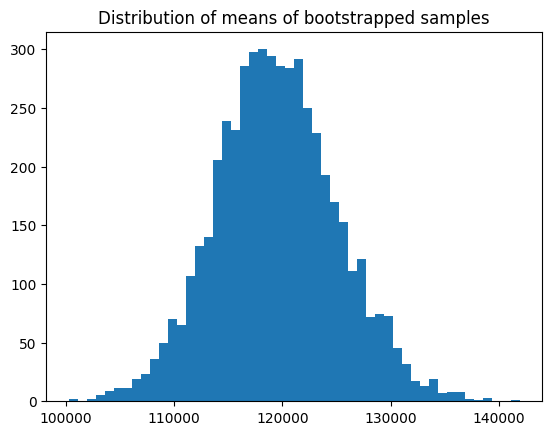

In [5]:
# visualizing the bootstrapped distribution
plt.hist(means_of_bstp, bins=50)
plt.title("Distribution of means of bootstrapped samples")
plt.show()

>The means of the 5K bootstrapped samples appear normally distributed.

>Notice that the mean of the bootstrapped means appears different than the hypothesized value($110K). 

In [6]:
# Calculating standard error
std_err = np.std(means_of_bstp, ddof=1)
std_err

np.float64(5618.828980861998)

NOTE: ideally, std_err is found using formula $SE = \frac{\sigma}{\sqrt{n}}$. The division by $\sqrt{n}$ is to "guess" how much the mean would vary if you took many more samples.

However in case of bootstrapped-sample, the"many more samples" are already simulated. Thus, division by $\sqrt{n}$ is not required.

### z-scores
>The z-score is a standardized measure that tells us how many standard deviations away from the mean a particular data point lies.

Before testing our hypothesis, we'll be standarding the values using z-scores.

Using a slightliy modified version of the z-score:
$z = \frac{\text{Sample stat} - \text{Hypothsized param value}}{\text{Standard error}}$

Note: that standard error $(SE = \frac{\sigma}{\sqrt{n}})$ quantifies the precision of a sample statistic (usually the mean) in representing the true population parameter.

In [7]:
# using variables to fit into above formula
print(f"The actual mean of population is = {np.round(mean_comp_sample,2)}\n")

print(f"Standard error (precision of sample mean) = {np.round(std_err,2)}\n")

# the hypothsized value being tested
hyp_mean_comp = 110000
print(f"Hypothesized compensation mean = {np.round(hyp_mean_comp,2)}\n")

# calculatng z-score
z_score = (mean_comp_sample - hyp_mean_comp) / std_err
print(f"Calculated z-score = {np.round(z_score,2)}")

The actual mean of population is = 119574.72

Standard error (precision of sample mean) = 5618.83

Hypothesized compensation mean = 110000

Calculated z-score = 1.7


>Thus ,we'll be working to understand whether the z-score (~1.71) is a high or low number
>
>i.e. Whether the sample statistic (mean) is close or far away from the hypothesized value.

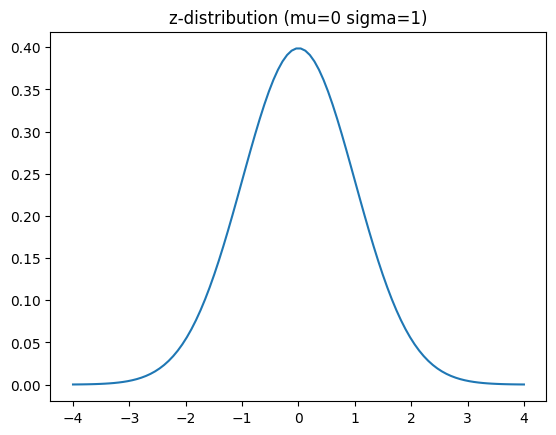

In [8]:
from scipy.stats import norm
mu=0
sigma=1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.title("z-distribution (mu=0 sigma=1)")
plt.plot(x,y)
plt.show()


In the `stackoverflow` dataset, `age_first_code_cut` classifies when the user first started programming.

Previous research: 35% of software devs started programming as children

This raises a question that can be answered using our current dataset -<br>
**_Does the sample provide evidence that a greater proportion of data scientists started programming as children?_**

A hypothesis test is a test of two competing hypotheses -- the Null hypothesis $(H_0)$ i.e. an existing idea and an Alternative hypothesis $(H_A)$ is the new 'challenger' idea.

>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

____
### p-values

The smaller the p-value, the stronger the evidence against the null hypothesis.

In below scenario: <br>
- $(H_0)$ : proportion of data scientists who started programming as children is 35%
- $(H_A)$ : proportion of data scientists who started programming as children is **greater than 35%**

Only one of the hypotheses can be true. $(H_0)$ is assumed to be initially true unless proven false -- in which case we reject it in favour of $(H_A)$.

In [26]:
stackoverflowdf["age_first_code_cut"].value_counts(normalize=True)

age_first_code_cut
adult    0.60858
child    0.39142
Name: proportion, dtype: float64

In [27]:
(stackoverflowdf["age_first_code_cut"]=="child").count()


np.int64(2261)

In [81]:
# assumed value
kidprog_hyp = 0.35

# Creating a list of bootstrapped-sampled means
kidprog_means = []

# taking 5K mean of bootstrapped samples
for i in range(5000):
    kidprog_means.append(
        np.mean(stackoverflowdf.sample(frac=1, replace=True)
                ["age_first_code_cut"]=="child"))

print(kidprog_means)

[np.float64(0.39451570101724903), np.float64(0.4007076514816453), np.float64(0.40468819106590004), np.float64(0.39141972578505085), np.float64(0.37947810703228657), np.float64(0.3980539584254755), np.float64(0.3892083149049093), np.float64(0.38567005749668287), np.float64(0.3816895179124281), np.float64(0.39451570101724903), np.float64(0.38876603272888105), np.float64(0.39584254754533393), np.float64(0.39451570101724903), np.float64(0.3874391862007961), np.float64(0.38567005749668287), np.float64(0.3816895179124281), np.float64(0.38080495356037153), np.float64(0.40601503759398494), np.float64(0.4011499336576736), np.float64(0.3790358248562583), np.float64(0.40203449800973023), np.float64(0.3892083149049093), np.float64(0.39053516143299427), np.float64(0.38124723573639985), np.float64(0.4029190623617868), np.float64(0.3923042901371075), np.float64(0.4011499336576736), np.float64(0.40336134453781514), np.float64(0.3918620079610792), np.float64(0.37815126050420167), np.float64(0.400265369

In [ ]:
# proportion of DS from the dataset who started coding as kids 
# part_child_sample_mean = (stackoverflowdf["age_first_code_cut"]=="child").mean()
part_child_sample_mean = np.mean(kidprog_means)

# The hypothesized significance level
kidprog_alpha = 0.05

# Standard error for stackoverflow["age_first_code"] column
kidprog_stderr = np.std(kidprog_means, ddof=1)

print(f"Avg. age of programmers who started coding as child = {part_child_sample_mean:.3f}\n")
print(f"Proposed hypothesized (mean) value = {kidprog_hyp}\n")
print(f"Considered significance value (alpha) = {kidprog_alpha}\n")
print(f"Bootsrap sample std (SE) = {kidprog_stderr}")

Avg. age of programmers who started coding as child = 0.391

Proposed hypothesized (mean) value = 0.35

Considered significance value (alpha) = 0.05

Bootsrap sample std (SE) = 0.010326820962294092


In [ ]:
# calculating z-score
stckovrflw_zscore = (part_child_sample_mean - kidprog_hyp)/kidprog_stderr
print(f"z-score = {stckovrflw_zscore}")

z-score = 4.010888339817749


In [91]:
# calculating the p-value
from scipy.stats import norm
kidprog_pval = 1 - norm.cdf(stckovrflw_zscore, loc=0, scale=1)
print(f"The p-value is {kidprog_pval}")

The p-value is 3.0245357746538915e-05


In [92]:
# comparing with hypothesized value
kidprog_pval <= kidprog_alpha

np.True_

So p-value is less than hypothesized value.

> Thus , we reject $H_{0}$ in favour of $H_{A}$

i.e. the porportion of data scientists who started coding early on in their childhood is certainly greater than 35%.

### Confidence intervals of $\alpha$

$\alpha$ of 0.05% means 95% confidence interval.

**False positive:** Actual correct hypothesis is $H_{0}$ but we supported $H_{A}$<br>
*This is called a Type I error*

**False negative:** Actual correct hypothesis is $H_{A}$ but we supported $H_{0}$<br>
*This is called a Type II error*

In [93]:
ci_low = np.quantile(kidprog_means, 0.025)

ci_high = np.quantile(kidprog_means, 0.975)

print(f"Confidence interval: ({ci_low:.3f}, {ci_high:.3f})")

Confidence interval: (0.371, 0.411)


>Since our hypothesized value (0.35) lies outside the 95% CI (0.372 – 0.411), we can reject the $H_{0}$ 

>The evidence strongly supports that more than 35% of data scientists started coding as children — our sample proportion of 39.1% is not due to chance.

In our case, it could happen that only the sample we chose had higher proportions of DS who began coding as a kid. The reality could different than our hypothesis ($H_{A}$).

So, despite $p \le \alpha$ & us rejecting $H_{0}$, it could be that there's a far smaller proportion of DS who'd started coding as a kid. Maybe we didn't consider a sufficiently large sample size.  Thus, its possible we made **a false positive error** or a **Type I error**.

____________
### Results of Hypothesis testing

For hypothesis tests and for criminal trials, there are two states of truth and two possible outcomes. 

Two combinations are correct test outcomes, and there are two ways it can go wrong.

**False positive:** Actual correct hypothesis is $H_{0}$ but we supported $H_{A}$<br>
*This is called a Type I error*

**False negative:** Actual correct hypothesis is $H_{A}$ but we supported $H_{0}$<br>
*This is called a Type II error*

In [96]:
(a,b) = (8,9)

9


_____
## Two-sample & ANOVA tests
## Two-sample testing
$H_{0}$: The mean compensation (in USD) is the same for those that coded first as a child andthose that coded first as an adult.

$H_{0}$ : $\mu_{child} = \mu_{adult}$  or  $H_{0}$ : $\mu_{child} - \mu_{adult} = 0$<br>

$H_{A}$: The mean compensation (in USD) is greater for those that coded first as a childcompared to those that coded first as an adult.

$H_{0}$ : $\mu_{child} > \mu_{adult}$  or  $H_{0}$ : $\mu_{child} - \mu_{adult} > 0$<br>


### Performing t-tests